Compute mean connectivity from HCP7T dataset

In [1]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from glob import glob

In [30]:
tian_scale = 'S2'

lut_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-carpet',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-carpet_lut.tsv')

region_list = list(pd.read_csv(lut_fpath, sep='\t', header=None).iloc[:,1])

In [32]:
region_list

['aPUT-lh',
 'pPUT-lh',
 'aCAU-lh',
 'pCAU-lh',
 'aPUT-rh',
 'pPUT-rh',
 'aCAU-rh',
 'pCAU-rh',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGa',
 'L-STGp',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGa',
 'R-STGp',
 'L-LOCsup',
 'L-LOCinf',
 'L-IntraCalc',
 'L-TempOccFus',
 'L-OccFus',
 'L-SupraCalc',
 'L-OccPole',
 'R-LOCsup',
 'R-LOCinf',
 'R-IntraCalc',
 'R-TempOccFus',
 'R-OccFus',
 'R-SupraCalc',
 'R-OccPole']

In [33]:
data_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                        'HCP_7T_diffusion/msmt_csd_nthreads-1/')

## Read in participant connectivity matrices

In [13]:
print(data_dir + 
      '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv')

/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1//*/connectome_streamlines_alg-iFOD2_nsl-10mil/atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv


In [53]:
conn_files = sorted(glob(data_dir + 
                         '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         f'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv'))

# derive participant IDs directly from conn_files (preserves same order)
participants_with_files = sorted(list({os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(p)))) for p in conn_files}))


In [20]:
print(len(conn_files))

96


In [21]:
test_df = pd.read_csv(conn_files[0])

In [22]:
test_df = pd.read_csv(conn_files[0], header=None)
print(test_df)
print(len(test_df))


              0             1             2              3   4   \
0   10510.091903      4.789509      8.715829    1351.807068   0   
1       4.789509  36798.350583     78.821834    2430.760723   0   
2       8.715829     78.821834  90705.159465   36009.550087   0   
3    1351.807068   2430.760723  36009.550087  183556.006466   0   
4       0.000000      0.000000      0.000000       0.000000   0   
5      18.597513  13553.163780  35970.119521   22664.321937   0   
6    4333.455680    453.115341    259.036399    2132.862154   0   
7   12894.037632     28.169667     44.473564    3508.155869   0   
8    1684.342466     36.752932     23.679187     613.753506   0   
9     371.008474     39.543466    334.928486    3594.353820   0   
10     11.160290  11885.877048     28.087197    3121.713585   0   
11      7.685450   1000.258638   8253.409178    4492.282018   0   
12      0.000000      0.000000      0.000000       0.976126   0   
13      0.485927    765.874920      0.000000      24.255821   

In [23]:
# loop through each subject's connectivity matrix and clean up the formatting
num_regions = len(test_df) # number of regions of interest in the HCP analysis
num_subjects = len(conn_files)
connmats = np.zeros((num_subjects, num_regions, num_regions))
slcounts = np.zeros((num_regions, num_subjects))
list_df = []
for sx, matrix_fpath in enumerate(conn_files):

    sub_df = pd.read_csv(matrix_fpath, header=None)
    list_df.append(sub_df)
    
    connmats[sx,:,:] = sub_df.to_numpy()
    
    slcounts[:,sx] = sub_df.to_numpy().sum(axis=0) # sub_df.iloc[:,0]

In [24]:
np.shape(connmats)

(96, 32, 32)

In [25]:
# check the streamline count matrix (region x subject)
slcounts

array([[ 34398.29994336,  23263.31132376,  24861.16649073, ...,
         35793.93841322,  29819.23509222,  31943.41634364],
       [ 70591.7149433 ,  54771.69384205,  68739.61841005, ...,
         55250.94553526,  31092.70814885,  50858.34116003],
       [188658.14971261, 107115.34962955, 117056.40232274, ...,
        153020.96958309, 134518.6121503 , 150919.08775885],
       ...,
       [ 12133.60814677,   5048.8245296 ,   7116.40823966, ...,
          5354.1840366 ,   5703.87854423,   6064.27543727],
       [ 28763.03932369,  24509.68719753,  33928.22103077, ...,
         25780.12580422,  29324.91321199,  29391.99721096],
       [ 34382.96149534,  29237.09310755,  38229.30985272, ...,
         25118.41600846,  32623.82849026,  26572.92486732]])

## Compute mean streamline count per ROI

In [26]:
# compute the mean streamline count per IC subdivision
mean_slcount = slcounts.mean(axis=1)
print(mean_slcount)
print(mean_slcount.shape)

[ 31138.39861572  58530.98324191 126478.11339862 212570.166592
      0.         178431.71096165  39915.62196691  53071.23070819
  29749.3447293   43975.28375636  21933.51250449  66301.36936387
  30226.34634097  58316.64468227 126264.16652245 181189.24513781
 115698.48228528 123946.29532795  34048.49835025  47426.35879302
  18268.85416923  55617.39741986  17430.83669288  60444.18258403
   7851.11057802   8580.06767804  12496.57523319  15758.03485555
   5469.20563153   7084.28602781  25237.35089735  28045.16721332]
(32,)


In [27]:
mean_connmat = connmats.mean(axis=0)

print(mean_connmat)
print(mean_connmat.shape)

[[9.62272954e+03 6.60558195e+00 2.17699479e+01 ... 4.08688144e-01
  3.10737502e+03 3.18311435e+00]
 [6.60558195e+00 2.22748463e+04 2.06175946e+02 ... 8.85977090e-02
  4.06215499e+02 1.05526261e+01]
 [2.17699479e+01 2.06175946e+02 5.51536575e+04 ... 4.79003258e-02
  4.21024764e+02 1.44916022e-02]
 ...
 [4.08688144e-01 8.85977090e-02 4.79003258e-02 ... 3.03181930e+03
  2.39522361e+01 7.83268510e+02]
 [3.10737502e+03 4.06215499e+02 4.21024764e+02 ... 2.39522361e+01
  3.46458857e+03 4.75062311e+01]
 [3.18311435e+00 1.05526261e+01 1.44916022e-02 ... 7.83268510e+02
  4.75062311e+01 3.61614949e+03]]
(32, 32)


In [34]:

# add ROI names to df
mean_df = pd.DataFrame(mean_connmat, columns=region_list)
mean_df.insert(0, 'seed', region_list)
mean_df.insert(0, 'mean_slcount', mean_slcount)


In [35]:
mean_df

,mean_slcount,seed,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,31138.398616,aPUT-lh,9622.729544,6.605582,21.769948,962.948474,0.0,25.473017,5236.629751,10146.536355,...,1.069561,0.095339,5.701020,0.141974,96.787652,0.032247,7.244493,0.408688,3107.375017,3.183114
1,58530.983242,pPUT-lh,6.605582,22274.846261,206.175946,3373.693041,0.0,13657.567786,393.711299,18.259410,...,761.495743,194.203558,16.702288,2.036264,399.972814,0.770957,8.967583,0.088598,406.215499,10.552626
2,126478.113399,aCAU-lh,21.769948,206.175946,55153.657529,30059.975967,0.0,16853.338466,335.718822,73.139107,...,8.484435,1.333291,5.110067,0.009518,200.181074,0.069769,12.137049,0.047900,421.024764,0.014492
3,212570.166592,pCAU-lh,962.948474,3373.693041,30059.975967,139454.685205,0.0,14701.769009,2860.825373,1862.116433,...,315.322591,13.893335,36.599742,0.211044,679.786622,0.035866,255.941628,2.238005,4538.431981,10.067280
4,0.000000,aPUT-rh,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,178431.710962,pPUT-rh,25.473017,13657.567786,16853.338466,14701.769009,0.0,103086.356857,1549.279797,63.565084,...,373.545170,7.905554,0.005728,0.003282,190.674613,0.002759,9.637456,0.000000,2819.797004,0.490100
6,39915.621967,aCAU-rh,5236.629751,393.711299,335.718822,2860.825373,0.0,1549.279797,11742.021636,3164.081508,...,1.172329,0.355285,48.354740,2.288174,1027.428643,3.685588,84.135012,2.340054,4216.621598,4.764960
7,53071.230708,pCAU-rh,10146.536355,18.259410,73.139107,1862.116433,0.0,63.565084,3164.081508,21951.137455,...,1.087018,0.229487,16.253318,0.272597,192.370476,0.074094,21.933935,1.082759,1282.266729,6.628328
8,29749.344729,L-HG,1397.476964,117.119151,130.758230,1073.268229,0.0,188.391755,6529.111275,3991.395801,...,0.109941,0.000000,2.986049,0.020421,27.437486,0.157805,3.005927,0.024072,235.202642,0.102939
9,43975.283756,L-PP,453.873832,26.216787,230.221993,2206.190392,0.0,156.316543,1657.026894,10170.940595,...,0.156257,0.030143,2.330580,0.005227,41.708737,0.006933,6.556962,0.014880,134.032678,0.043349


In [38]:
# save the mean data
out_dir = os.path.join(data_dir, 'group_plots_Nov')
out_fpath = os.path.join(out_dir, 'pd_mean_connectivity.txt')
os.makedirs(out_dir, exist_ok=True)
mean_df.to_csv(out_fpath, sep='\t', index=False)

In [39]:
out_dir

'/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/group_plots_Nov'

### Plot distributions

In [40]:
import seaborn as sns

In [41]:
connmats.shape

(96, 32, 32)

<Axes: >

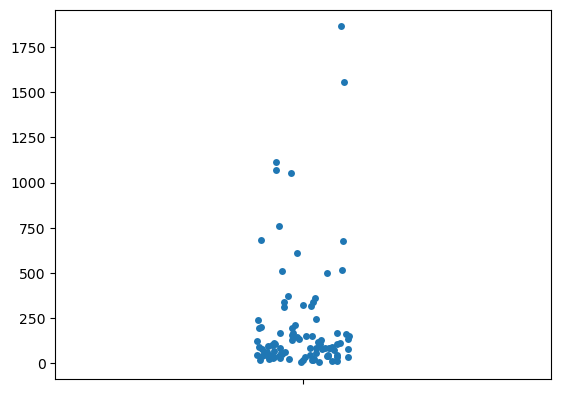

In [42]:
sns.stripplot(connmats[:,1,2])

## Combine separate participants into single dataframe

In [20]:
len(connmats)

100

In [43]:
connmats.shape

(96, 32, 32)

In [44]:
m,n,r = connmats.shape

out_arr = np.column_stack((np.repeat(np.arange(m),n),connmats.reshape(m*n,-1)))
out_df = pd.DataFrame(out_arr)

In [45]:
out_df

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,0.0,10510.091903,4.789509,8.715829,1351.807068,0.0,18.597513,4333.455680,12894.037632,1684.342466,...,0.342238,0.000000,4.357843,0.000000,65.834432,0.280541,19.704495,0.334354,3104.246460,0.671902
1,0.0,4.789509,36798.350583,78.821834,2430.760723,0.0,13553.163780,453.115341,28.169667,36.752932,...,547.171916,42.141571,4.721164,0.590260,90.950853,0.000000,2.565982,0.347760,542.214098,0.000000
2,0.0,8.715829,78.821834,90705.159465,36009.550087,0.0,35970.119521,259.036399,44.473564,23.679187,...,0.000000,0.000000,3.851062,0.000000,94.819992,0.000000,9.424153,0.000000,568.949849,0.000000
3,0.0,1351.807068,2430.760723,36009.550087,183556.006466,0.0,22664.321937,2132.862154,3508.155869,613.753506,...,122.174286,0.000000,53.154977,0.000000,513.955305,0.000000,515.911364,0.401266,5035.798636,0.487563
4,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3067,95.0,0.000000,0.000000,0.000000,0.184971,0.0,0.000000,15.255474,0.000000,0.000000,...,15.476941,85.607743,52.067805,1563.556992,21.700044,7278.052171,3.127843,103.764201,16.825915,2401.356547
3068,95.0,2.236372,10.689127,15.297942,489.967532,0.0,6.484462,35.541545,10.547854,0.533833,...,0.354749,0.000000,1479.920558,4.554973,94.591985,3.127843,2010.748991,24.051652,396.984911,14.171752
3069,95.0,0.268130,0.000000,0.000000,11.615605,0.0,0.000000,0.636778,1.011845,0.000000,...,2.803120,5.222513,4.550496,1950.454928,4.764744,103.764201,24.051652,2942.062109,14.500177,384.000869
3070,95.0,7910.954109,526.600294,182.380901,2824.991100,0.0,3435.805387,5145.041609,2812.394815,235.593956,...,3.531352,0.897730,51.275099,8.700454,1492.581742,16.825915,396.984911,14.500177,2704.476361,18.070163


In [49]:
print(len(out_df))

3072


In [54]:
# derive participant ids from conn_files (preserves same order as connmats)
participant_ids = [os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(p)))) for p in conn_files]
print('Using', len(participant_ids), 'participant IDs derived from connectivity files')
participant_ids[:20]

Using 96 participant IDs derived from connectivity files


['100610',
 '102311',
 '102816',
 '104416',
 '105923',
 '108323',
 '109123',
 '111312',
 '111514',
 '114823',
 '115017',
 '115825',
 '116726',
 '118225',
 '125525',
 '126426',
 '126931',
 '128935',
 '130114',
 '130518']

In [55]:
participant_df_list = []
# add ROI names to df
for i, participant_id in enumerate(participant_ids):
    single_df = pd.DataFrame(connmats[i], columns=region_list)
    single_df.insert(0, 'seed', region_list)
    single_df.insert(0, 'slcount', mean_slcount)
    single_df.insert(0, 'participant_id', participant_id)
    participant_df_list.append(single_df)
all_df = pd.concat(participant_df_list)

In [56]:
# save the participant-level data
out_dir = os.path.join(data_dir, 'group_plots_Nov')
out_fpath = os.path.join(out_dir, 'pd_participant_connectivity.txt')
os.makedirs(out_dir, exist_ok=True)
all_df.to_csv(out_fpath, sep='\t', index=False)

In [57]:
print(out_fpath)

/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1/group_plots_Nov/pd_participant_connectivity.txt
